## Topic : Factors Influencing Public Trust in Society

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [193]:
data = pd.read_csv("data.csv")
data1 = pd.read_csv("data1.csv")
data2 = pd.read_csv("data2.csv")
data3 = pd.read_csv("data3.csv")

data y (outcome) : Percentage of population who think most people can be trusted

x1 : GDP rate per capita

In [194]:
data.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,_O,Other,AND,Andorra,WB_SSGD_PCT_POP_TRUST,Percentage of population who think most people...,_T,...,Units,RATIO,Ratio,602,CCYY,NaN,A,Normal value,PU,Public


In [195]:
print(data.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID',
       'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE',
       'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS',
       'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')


### Cleaning the data (y)

In [196]:
df = data[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
df.columns = ['Country', 'Year', 'Trust']
df = df.dropna()
df

,Country,Year,Trust
0,Andorra,2018,23.214285
1,Andorra,2018,23.308271
2,Andorra,2018,25.714287
3,Andorra,2018,30.239519
4,Andorra,2018,28.054300
...,...,...,...
1634,Zimbabwe,2021,2.478915
1635,Zimbabwe,2021,3.826917
1636,Zimbabwe,2021,3.725705
1637,Zimbabwe,2021,2.749519


### Filter only total population

In [197]:
print(data['SEX_LABEL'].unique())
print(data['AGE_LABEL'].unique())

['Total' 'Male' 'Female']
['All age ranges or no breakdown by age' '60 years old and over'
 '25 years old and over' '15 to 24 years old' '30 to 59 years old'
 '15 to 29 years old']


In [198]:
df = data[
    (data['SEX_LABEL'] == 'Total') &
    (data['AGE_LABEL'] == 'All age ranges or no breakdown by age') &
    (data['URBANISATION_LABEL'] == 'Total')
][['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]

df.columns = ['Country', 'Year', 'Trust']

# Filter year
df = df[df['Year'] == 2018]

df = df.groupby(['Country', 'Year'])['Trust'].mean().reset_index()
df['Country'] = df['Country'].replace({
    'Viet Nam': 'Vietnam'
})

In [199]:
df

,Country,Year,Trust
0,Andorra,2018,30.130722
1,Argentina,2018,19.855508
2,Bangladesh,2018,20.720835
3,Bolivia,2018,15.944298
4,Brazil,2018,4.509698
5,Chile,2018,13.981507
6,Colombia,2018,19.739761
7,Costa Rica,2018,10.194100
8,Dominican Republic,2018,13.992673
9,Ecuador,2018,15.486740


In [200]:
df['Country'].unique()

array(['Andorra', 'Argentina', 'Bangladesh', 'Bolivia', 'Brazil', 'Chile',
       'Colombia', 'Costa Rica', 'Dominican Republic', 'Ecuador',
       'El Salvador', 'Guatemala', 'Honduras', 'Kazakhstan', 'Mexico',
       'Mongolia', 'Nicaragua', 'Pakistan', 'Panama', 'Paraguay', 'Peru',
       'Philippines', 'Puerto Rico', 'Romania', 'Turkiye', 'Uruguay',
       'Venezuela, RB', 'Vietnam'], dtype=object)

data1 x1 : GDP rate per capita

In [201]:
data1.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VEN,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VNM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [202]:
print(data1.columns)

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'AGG_METHOD',
       'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'COMMENT_TS',
       'UNIT_MULT', 'DATA_SOURCE', 'OBS_CONF', 'OBS_VALUE', 'OBS_STATUS',
       'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'SEX_LABEL',
       'AGE_LABEL', 'URBANISATION_LABEL', 'UNIT_MEASURE_LABEL',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL',
       'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL',
       'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL'],
      dtype='object')


In [203]:
gdp_data = data1[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
gdp_data.columns = ['Country', 'Year', 'GDP']
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2011,4.176425
1,Vietnam,2011,6.413169
2,Virgin Islands (U.S.),2011,-8.204246
3,West Bank and Gaza,2011,9.600808
4,"Yemen, Rep.",2011,-12.714897
...,...,...,...
14128,"Venezuela, RB",2024,5.300000
14129,Vietnam,2024,7.091187
14130,West Bank and Gaza,2024,-26.557526
14131,Zambia,2024,3.820048


In [204]:
gdp_data = gdp_data[gdp_data['Year'] == 2018]
gdp_data

,Country,Year,GDP
102,Uzbekistan,2018,5.559196
103,Vanuatu,2018,2.900230
104,"Venezuela, RB",2018,-19.655342
105,Vietnam,2018,7.465007
106,Virgin Islands (U.S.),2018,1.878307
...,...,...,...
6186,Late-demographic dividend,2018,5.439785
6187,Latin America & Caribbean,2018,1.217913
6188,Latin America & Caribbean (excluding high income),2018,1.544157
6189,Latin America & Caribbean (IDA & IBRD),2018,1.302503


In [205]:
valid_countries = df['Country'].unique()
gdp_data = gdp_data[gdp_data['Country'].isin(valid_countries)]
gdp_data = gdp_data.reset_index(drop=True)

In [206]:
gdp_data

,Country,Year,GDP
0,"Venezuela, RB",2018,-19.655342
1,Vietnam,2018,7.465007
2,Bolivia,2018,2.868084
3,Mongolia,2018,7.744881
4,Kazakhstan,2018,4.100000
5,Chile,2018,3.990029
6,Colombia,2018,2.564324
7,Costa Rica,2018,2.615904
8,Guatemala,2018,3.406873
9,Nicaragua,2018,-3.363357


x2 : Expected years of schooling

In [207]:
data2.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ_ID,FREQ_NAME,REF_AREA_ID,REF_AREA_NAME,INDICATOR_ID,INDICATOR_NAME,SEX_ID,...,DATABASE_ID_ID,DATABASE_ID_NAME,UNIT_MULT_ID,UNIT_MULT_NAME,UNIT_TYPE_ID,UNIT_TYPE_NAME,OBS_STATUS_ID,OBS_STATUS_NAME,OBS_CONF_ID,OBS_CONF_NAME
0,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,ABW,Aruba,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFE,Africa Eastern and Southern,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFG,Afghanistan,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AFW,Africa Western and Central,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.1),I,A,Annual,AGO,Angola,WB_GS_SE_SCH_LIFE,Expected years of schooling,_T,...,WB_GS,Gender Statistics,0,Units,COUNT,Count (Integer),O,Missing value,PU,Public


In [208]:
edu_clean = data2[data2['SEX_ID'] == '_T']

In [209]:
edu_clean = edu_clean[['REF_AREA_NAME', 'TIME_PERIOD', 'OBS_VALUE']]
edu_clean.columns = ['Country', 'Year', 'Education']

In [210]:
edu_clean = edu_clean[edu_clean['Year'] == 2018]
edu_clean = edu_clean.dropna()
edu_clean

,Country,Year,Education
46112,Afghanistan,2018,10.537860
46113,Africa Western and Central,2018,8.709350
46115,Albania,2018,15.107830
46116,Andorra,2018,11.927510
46117,Arab World,2018,11.181970
...,...,...,...
46359,Uruguay,2018,16.269159
46360,United States,2018,16.642851
46361,Uzbekistan,2018,12.128460
46368,World,2018,12.174770


In [211]:
valid_countries = df['Country'].unique()
edu_clean = edu_clean[edu_clean['Country'].isin(valid_countries)]
edu_clean = edu_clean.reset_index(drop=True)

In [212]:
edu_clean

,Country,Year,Education
0,Andorra,2018,11.927510
1,Argentina,2018,17.857821
2,Bangladesh,2018,11.399190
3,Brazil,2018,15.503760
4,Chile,2018,16.606211
5,Colombia,2018,14.628640
6,Costa Rica,2018,15.228420
7,Ecuador,2018,14.725050
8,Kazakhstan,2018,14.350610
9,Mexico,2018,14.923050


X3 : Unemployment rate

In [213]:
data3

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AFG,Afghanistan,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ALB,Albania,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,DZA,Algeria,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AND,Andorra,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AGO,Angola,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,VNM,Viet Nam,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,F,Forecast value,PU,Public
9796,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,PSE,West Bank and Gaza,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,Source: National Statistics Office Latest actu...,O,Missing value,PU,Public
9797,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,YEM,"Yemen, Rep.",IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public
9798,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,ZMB,Zambia,IMF_WEO_LUR,"Unemployment rate, Percent of total labor force",_T,...,Units,RATIO,Ratio,602,CCYY,NaN,O,Missing value,PU,Public


In [230]:
data3.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA',
       'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL',
       'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL',
       'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL',
       'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD',
       'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'COMMENT_TS',
       'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL',
       'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS',
       'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL'],
      dtype='object')

In [221]:
unemp = data3[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp

,Country,Year,Unemployment
0,Afghanistan,1980,NaN
1,Albania,1980,5.028
2,Algeria,1980,15.789
3,Andorra,1980,NaN
4,Angola,1980,NaN
...,...,...,...
9795,Viet Nam,2029,1.933
9796,West Bank and Gaza,2029,NaN
9797,"Yemen, Rep.",2029,NaN
9798,Zambia,2029,NaN


In [226]:
unemp = unemp[unemp['Year'] == 2018]
unemp = unemp.dropna()
unemp

,Country,Year,Unemployment
7449,Albania,2018,12.300
7450,Algeria,2018,11.731
7451,Andorra,2018,1.775
7454,Argentina,2018,9.200
7455,Armenia,2018,19.000
...,...,...,...
7635,Uruguay,2018,8.367
7636,Uzbekistan,2018,9.347
7638,"Venezuela, RB",2018,35.554
7639,Viet Nam,2018,2.190


In [228]:
unemp = data3[data3['SEX'] == '_T']
unemp = unemp[['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']]
unemp.columns = ['Country', 'Year', 'Unemployment']
unemp = unemp[unemp['Year'] == 2018].dropna()
unemp

,Country,Year,Unemployment
7449,Albania,2018,12.300
7450,Algeria,2018,11.731
7451,Andorra,2018,1.775
7454,Argentina,2018,9.200
7455,Armenia,2018,19.000
...,...,...,...
7635,Uruguay,2018,8.367
7636,Uzbekistan,2018,9.347
7638,"Venezuela, RB",2018,35.554
7639,Viet Nam,2018,2.190


In [231]:
print(unemp.head())
print(len(unemp))
print(unemp['Country'].nunique())

        Country  Year  Unemployment
7449    Albania  2018        12.300
7450    Algeria  2018        11.731
7451    Andorra  2018         1.775
7454  Argentina  2018         9.200
7455    Armenia  2018        19.000
111
111


### Merge all Xs, with the union countries

In [233]:
gdp_data = gdp_data.drop(columns=['Year'])
edu_clean = edu_clean.drop(columns=['Year'])
unemp = unemp.drop(columns=['Year'])

In [234]:
df_final = df.copy()

df_final = pd.merge(df_final, gdp_data, on='Country')
df_final = pd.merge(df_final, edu_clean, on='Country')
df_final = pd.merge(df_final, unemp, on='Country')

In [238]:
df_final

,Country,Year,Trust,GDP,Education,Unemployment
0,Andorra,2018,30.130722,1.588765,11.927510,1.775
1,Argentina,2018,19.855508,-2.617396,17.857821,9.200
2,Brazil,2018,4.509698,1.783667,15.503760,12.375
3,Chile,2018,13.981507,3.990029,16.606211,7.377
4,Colombia,2018,19.739761,2.564324,14.628640,9.942
5,Costa Rica,2018,10.194100,2.615904,15.228420,11.951
6,Ecuador,2018,15.486740,1.044295,14.725050,3.690
7,Kazakhstan,2018,23.130382,4.100000,14.350610,4.828
8,Mexico,2018,20.311960,1.972082,14.923050,3.321
9,Pakistan,2018,23.380464,6.151703,7.303080,5.800


In [237]:
len(df_final)

14

### Try plotting graph for each independent variable

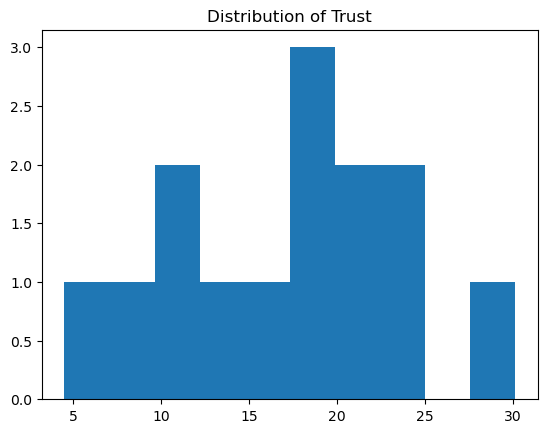

In [242]:
plt.hist(df_final['Trust'])
plt.title('Distribution of Trust')
plt.show()

### Trust VS GDP

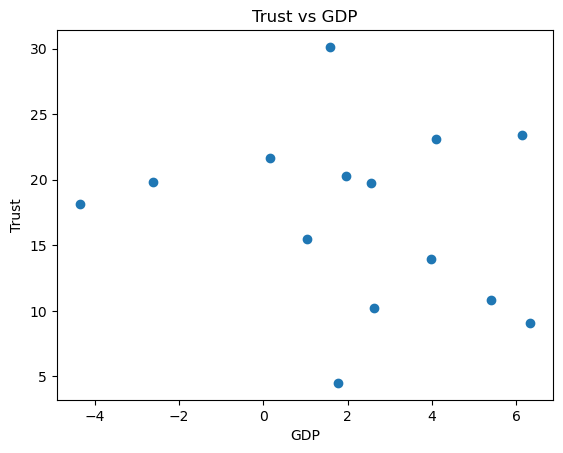

In [243]:
plt.scatter(df_final['GDP'], df_final['Trust'])
plt.xlabel('GDP')
plt.ylabel('Trust')
plt.title('Trust vs GDP')
plt.show()

### Trust VS Education

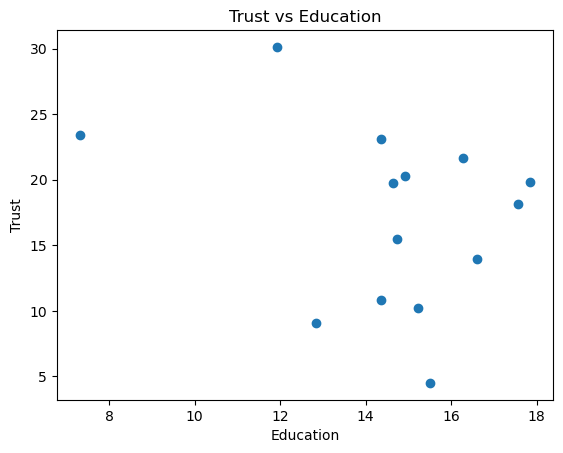

In [244]:
plt.scatter(df_final['Education'], df_final['Trust'])
plt.xlabel('Education')
plt.ylabel('Trust')
plt.title('Trust vs Education')
plt.show()

### Trust vs Unemployment

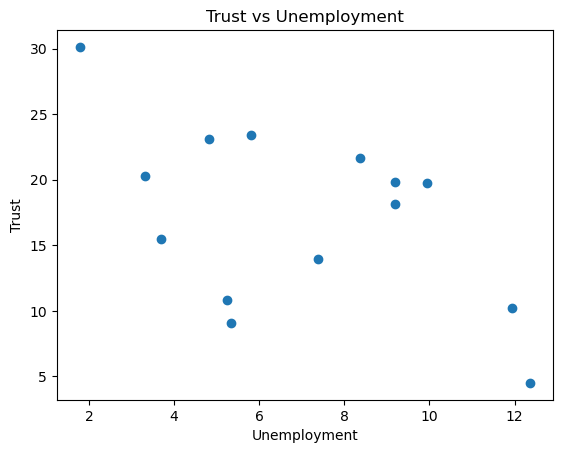

In [245]:
plt.scatter(df_final['Unemployment'], df_final['Trust'])
plt.xlabel('Unemployment')
plt.ylabel('Trust')
plt.title('Trust vs Unemployment')
plt.show()